#<STEP 0> 환경 설정

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
imageDir = 'track'; outDir = '/content/drive/MyDrive/ysuSemi/'+imageDir                 # Google Drive 에서 도로 이미지가 저장된 디렉터리 이름, 학습 파일, plot이미지 저장 위치


# <STEP 1>이미지 파일 압축 풀기 - 실행 하기 전 압축파일(*.zip)을 올려 놓아야 합니다.

In [3]:
EPOCHS = None;
learnRate = None                                                 # epochN = 300, learnRate = 0.0005/0.0010/0.0015/0.0020/0.0025
import glob
import zipfile
fileList = glob.glob(outDir+'/*.zip')
print(f'자율주행 프로젝트는 {len(fileList)} 개 입니다.')
for t in fileList:                                                              # 프로젝트 이름 프린트
    u = t.split('/'); v = u[-1]; w = v.split('.'); p = w[-2]; print(p)          # 파일 이름 추출 '/' 문자를 기준으로 분리하여 리스트 생성
project = input('자율주행 프로젝트 이름을 입력하세요:')                         # 자율 주행 프로젝트 이름 입력하고 [Enter]키 입력
if project == '': project = p                                                   # 이름 입력하지 않고 [Enter]키 입력하면 표시된 마지막 파일을 사용
local_zip =  outDir+'/'+project+'.zip'; print(local_zip)
zip_ref = zipfile.ZipFile(local_zip, 'r');
zip_ref.extractall()
zip_ref.close()
#w = local_zip.split('.'); project = w[-2]
print('프로젝트:',project)

자율주행 프로젝트는 24 개 입니다.
wayE
0926_ympark
2513890
2513890a
251127
2213648___
2414698
2512663
1125
2515507
newtrack2
trial5
24154332
track1125
chanseok
25151
2415012_2
KSJ2510237_1
2310302-
road4
2411035_2
2410110
24shA1
251128
자율주행 프로젝트 이름을 입력하세요:251128
/content/drive/MyDrive/ysuSemi/track/251128.zip
프로젝트: 251128


# <STEP 2> 라이브러리 가져오기(Import)

In [4]:
import os
import sys
import random
import fnmatch
import pickle
import time
import numpy as np
import cv2                                                                      # Open Cv 영상처리 라이브러리
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary as summary
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline
from PIL import Image

print(f'Python Version:     {sys.version}')                                     # Python Version
print(f'OpenCV version:     {cv2.__version__}')                                  # Open CV version
print(f'Pytorch version:    {torch.__version__}')                               # Pytorch version

Python Version:     3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OpenCV version:     4.12.0
Pytorch version:    2.9.0+cu126


# <STEP 3> 이미지 데이터 조향각 추출

In [5]:
with open(f'/content/{project}/_{project}.pickle', 'rb') as f:                           # pickle 파일
    x_exam_Image = pickle.load(f)                                               # 시험(Test) 이미지 파일 이름 리스트
    x_valid_Image = pickle.load(f)                                              # 평가(Valid) 이미지 파일 이름 리스트
    x_train_Image = pickle.load(f)                                              # 훈련(Train) 이미지 파일 이름 리스트
    p = pickle.load(f)                                                          # 파라메터 리스트
if EPOCHS == None: EPOCHS = p[0]                                                # 학습회수
if learnRate == None: learnRate = p[1]                                          # 학습 비율 0.0005/0.0010/0.0015/0.0020/0.0025
#-------------------------------------------------------------------------------
y_exam_Angle=[]
y_valid_Angle=[]
y_train_Angle = []
for f in x_exam_Image:                                                          # 시험용 이미지 파일 이름에서 각도값
    y_exam_Angle.append(int(f[-7:-4]))
for f in x_valid_Image:                                                         # 평가용 이미지 파일 이름에서 각도값
    y_valid_Angle.append(int(f[-7:-4]))
for f in x_train_Image:                                                         # 훈련용 이미지 파일 이름에서 각도값
    y_train_Angle.append(int(f[-7:-4]))

print('학습 회수:',EPOCHS,)
print('학습 비율', learnRate)
print('시험 이미지 개수:',len(x_exam_Image))
print('평가 이미지 개수:',len(x_valid_Image))
print('훈련 이미지 개수:',len(x_train_Image))

학습 회수: 300
학습 비율 0.001
시험 이미지 개수: 6
평가 이미지 개수: 329
훈련 이미지 개수: 989


#<STEP 4> 딥러닝 모델 구현

In [6]:
# Pytorch device 설정
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'{device} is available')

cuda:0 is available


## 1) Nvidia CNN 모델
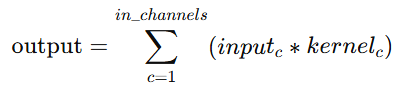

In [7]:
# Nvidia CNN 모델 구성 ---------------------------------------------------------
class NvidiaModel(nn.Module):
    def __init__(self):
      super(NvidiaModel, self).__init__()

      # elu=Expenential Linear Unit, similar to leaky Relu
      # skipping 1st hiddel layer (nomralization layer), as we have normalized the data

      # Convolution Layers
      self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=24, kernel_size=(5, 5), stride=(2, 2)),
        nn.ELU(inplace=True),
        nn.Conv2d(in_channels=24, out_channels=36, kernel_size=(5, 5), stride=(2, 2)),
        nn.ELU(inplace=True),
        nn.Conv2d(in_channels=36, out_channels=48, kernel_size=(5, 5), stride=(2, 2)),
        nn.ELU(inplace=True),
        nn.Conv2d(in_channels=48, out_channels=64, kernel_size=(3, 3)),
        nn.ELU(inplace=True),
        nn.Dropout(0.2),
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3, 3)),
        nn.ELU(inplace=True)
      )

      # Fully Connected Layers
      self.layer2 = nn.Sequential(
        # nn.Flatten(),
        nn.Dropout(0.2),
        nn.Linear(in_features=18 * 64, out_features=100),
        nn.ELU(inplace=True),
        nn.Linear(in_features=100, out_features=50),
        nn.ELU(inplace=True),
        nn.Linear(in_features=50, out_features=10),
        nn.ELU(inplace=True)
      )

      # Output Layer
      self.layer3 = nn.Sequential(
        nn.Linear(in_features=10, out_features=1)
      )

    def forward(self, x):
      x = self.layer1(x)
      x = x.view(x.shape[0], -1)
      x = self.layer2(x)
      x = self.layer3(x)

      return x

## 2) MobileNet 모델
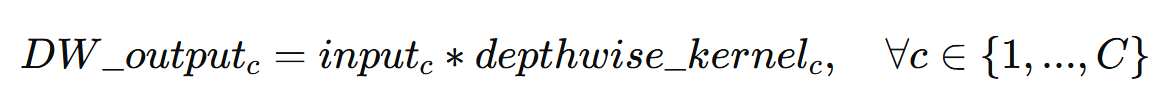
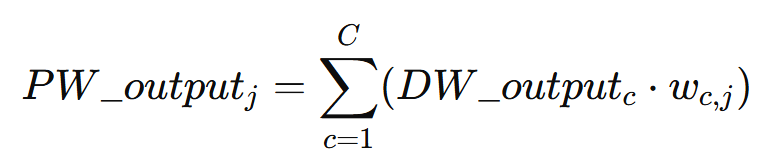

In [8]:
# Depthwise Separable Convolution 블록 정의
class DepthwiseSeparableConv(nn.Module):
    """
    MobileNet의 기본 블록:
    - Depthwise Conv (채널별 3x3)
    - Pointwise Conv (1x1, 채널 믹스)
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(DepthwiseSeparableConv, self).__init__()

        # Depthwise Convolution (groups = in_channels)
        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=in_channels,
            bias=False
        )

        #“각 채널별로 값의 평균과 분산을 계산하고
        # 정규화하는 레이어를 만들겠다”
        # 입력과 똑같은 크기의 feature map을 반환함
        # 모양은 그대로, 값만 정규화 + 조정(scale/shift)됨
        self.bn1 = nn.BatchNorm2d(in_channels)

        # Pointwise Convolution (1x1 Conv)
        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU(inplace=True)  # 필요하면 nn.ELU 로 바꿔도 됩니다.

    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.act(x)

        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.act(x)
        return x


In [9]:
# 간단한 MobileNet 스타일 모델 클래스
class MobileNetSmall(nn.Module):
    """
    NvidiaModel을 대체해서 사용할 수 있는
    간단한 MobileNet 스타일 모델 (출력: steering angle 1개)
    """
    def __init__(self, num_outputs=1, dropout_p=0.2):
        super(MobileNetSmall, self).__init__()

        # Stem: 처음 입력을 줄이는 부분 (3xHxW -> 32채널)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # MobileNet 스타일 블록들
        self.features = nn.Sequential(
            # in, out, stride
            DepthwiseSeparableConv(32, 64, stride=1),
            DepthwiseSeparableConv(64, 128, stride=2),
            DepthwiseSeparableConv(128, 128, stride=1),
            DepthwiseSeparableConv(128, 256, stride=2),
            DepthwiseSeparableConv(256, 256, stride=1),
            DepthwiseSeparableConv(256, 512, stride=2),
            # 필요에 따라 더 늘리거나 줄일 수 있음
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
        )

        # 전역 평균 풀링으로 feature map을 1x1로 압축
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 완전연결 레이어(steering angle 회귀)
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(512, num_outputs)

    def forward(self, x):
        # x: (batch, 3, H, W)
        x = self.stem(x)
        x = self.features(x)
        x = self.avgpool(x)          # (batch, 512, 1, 1)
        x = torch.flatten(x, 1)      # (batch, 512)
        x = self.dropout(x)
        x = self.fc(x)               # (batch, 1)  → 조향각
        return x


##3) EfficientNet 모델

In [10]:
# Squeeze-and-Excitation(SE) 블록
# 어떤 채널이 더 중요한지 판단하고,
# 그 채널에 가중치를 다시 주는 역할
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super(SEBlock, self).__init__()
        hidden = in_channels // reduction

        #각 채널의 전체 이미지를 하나의 대표 숫자(평균값)로 요약
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=1, bias=True), # 특징맵 축소
            nn.SiLU(inplace=True),  # Swish : 정보 학습을 부드럽게 조정
            nn.Conv2d(hidden, in_channels, kernel_size=1, bias=True), # 특징맵 확장
            nn.Sigmoid() #0~1 값으로 정규화 → 각 채널의 중요도를 확률처럼 표현
        )

    def forward(self, x):
        scale = self.avg_pool(x)
        scale = self.fc(scale)
        return x * scale


In [11]:
# MBConv 블록 (EfficientNet의 핵심)
class MBConvBlock(nn.Module):
    """
    EfficientNet의 기본 블록:
    - 확장(1x1 Conv, expand_ratio)
    - Depthwise Conv (3x3 or 5x5)
    - SE Block
    - Pointwise Conv (1x1, 출력 채널 조정)
    - skip connection (stride=1이고 in==out일 때)
    MBConv는 입력 특징을 잠깐 넓혔다가(확장),
    가볍게 처리하고(Depthwise),
    중요한 채널을 강조(SE),
    다시 줄인 후(Project),
    원본과 더해(Residual) 효율적이고 강력한 특징을 만드는 블록
    """
    def __init__(self, in_channels, out_channels, expand_ratio, stride, kernel_size=3, reduction=4):
        super(MBConvBlock, self).__init__()
        self.stride = stride
        self.use_res_connect = (self.stride == 1 and in_channels == out_channels)
        hidden_dim = in_channels * expand_ratio

        layers = []

        # 1. 확장 단계 (in -> hidden_dim)
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.SiLU(inplace=True)
            ])

        # 2. Depthwise Conv
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim,
                      kernel_size=kernel_size,
                      stride=stride,
                      padding=kernel_size // 2,
                      groups=hidden_dim,
                      bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU(inplace=True)
        ])

        self.pre_se = nn.Sequential(*layers)

        # 3. SE Block
        self.se = SEBlock(hidden_dim, reduction=reduction)

        # 4. Pointwise Conv (hidden_dim -> out_channels)
        self.project = nn.Sequential(
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        identity = x
        out = self.pre_se(x)
        out = self.se(out)
        out = self.project(out)

        if self.use_res_connect:
            out = out + identity
        return out


In [12]:
# EfficientNet 스타일 전체 모델 (조향각 회귀용)
class EfficientNetSmall(nn.Module):
    """
    자율주행 조향각(1개)을 예측하는 EfficientNet 스타일 모델.
    - 이미지 입력: (B, 3, H, W)
    - 출력: (B, 1)
    """
    def __init__(self, num_outputs=1, dropout_p=0.2):
        super(EfficientNetSmall, self).__init__()

        # 1. Stem (입력 줄이기)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True)   # Swish
        )

        # 2. EfficientNet-B0 스타일 설정 (조금 단순화)
        # (in_c, out_c, num_repeat, stride, expand_ratio, kernel_size)
        cfgs = [
            (32,   16, 1, 1, 1, 3),
            (16,   24, 2, 2, 6, 3),
            (24,   40, 2, 2, 6, 5),
            (40,   80, 3, 2, 6, 3),
            (80,  112, 3, 1, 6, 5),
            (112, 192, 3, 2, 6, 5),
            (192, 320, 1, 1, 6, 3),
        ]

        blocks = []
        for in_c, out_c, n, s, t, k in cfgs:
            # 첫 블록만 stride 사용
            blocks.append(MBConvBlock(in_c, out_c, expand_ratio=t, stride=s, kernel_size=k))
            # 나머지 반복 블록은 stride=1
            for _ in range(1, n):
                blocks.append(MBConvBlock(out_c, out_c, expand_ratio=t, stride=1, kernel_size=k))
        self.blocks = nn.Sequential(*blocks)

        # 3. Head (마지막 Conv)
        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, kernel_size=1, bias=False),
            nn.BatchNorm2d(1280),
            nn.SiLU(inplace=True)
        )

        # 4. Global Pool + FC(회귀)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(1280, num_outputs)

    def forward(self, x):
        # x : (B, 3, H, W)
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        x = self.avgpool(x)          # (B, 1280, 1, 1)
        x = torch.flatten(x, 1)      # (B, 1280)
        x = self.dropout(x)
        x = self.fc(x)               # (B, 1)  → 조향각
        return x


## 4) SuffleNet 모델

In [13]:
# Channel Shuffle 유틸 함수
def channel_shuffle(x, groups: int):
    """
    ShuffleNet에서 사용하는 채널 셔플 함수
    x: (B, C, H, W)
    groups: 그룹 개수 (보통 2)
    """
    batch_size, num_channels, height, width = x.size()
    channels_per_group = num_channels // groups

    # (B, groups, channels_per_group, H, W)
    x = x.view(batch_size, groups, channels_per_group, height, width)
    x = torch.transpose(x, 1, 2).contiguous()  # 그룹과 채널 축을 swap
    # (B, C, H, W) 형태로 다시 복원
    x = x.view(batch_size, -1, height, width)
    return x


In [14]:
# ShuffleNet v2 기본 블록
# stride = 1 인 블록
class ShuffleUnitV2(nn.Module):
    """
    ShuffleNet v2 기본 블록 (stride=1)
    - 입력 채널을 두 갈래로 나눠서 한쪽만 변환하고 다시 concat + shuffle
    """
    def __init__(self, channels: int):
        super(ShuffleUnitV2, self).__init__()
        self.channels = channels
        half = channels // 2

        self.branch2 = nn.Sequential(
            nn.Conv2d(half, half, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(half),
            nn.ReLU(inplace=True),

            nn.Conv2d(half, half, kernel_size=3, stride=1, padding=1, groups=half, bias=False),  # depthwise
            nn.BatchNorm2d(half),

            nn.Conv2d(half, half, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(half),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # 채널을 절반으로 split
        x1, x2 = x.chunk(2, dim=1)

        out2 = self.branch2(x2)

        out = torch.cat([x1, out2], dim=1)
        out = channel_shuffle(out, groups=2)
        return out


In [15]:
# stride = 2 인 다운샘플링 블록
class ShuffleUnitV2Down(nn.Module):
    """
    ShuffleNet v2 다운샘플링 블록 (stride=2)
    - 두 branch 모두 conv 수행 후 concat + shuffle
    """
    def __init__(self, in_channels: int, out_channels: int):
        super(ShuffleUnitV2Down, self).__init__()
        out_channels_branch = out_channels // 2

        # branch1: depthwise + pointwise
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=2, padding=1,
                      groups=in_channels, bias=False),  # depthwise
            nn.BatchNorm2d(in_channels),

            nn.Conv2d(in_channels, out_channels_branch, kernel_size=1, stride=1, padding=0,
                      bias=False),
            nn.BatchNorm2d(out_channels_branch),
            nn.ReLU(inplace=True)
        )

        # branch2: pointwise + depthwise + pointwise
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels_branch, kernel_size=1, stride=1, padding=0,
                      bias=False),
            nn.BatchNorm2d(out_channels_branch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels_branch, out_channels_branch, kernel_size=3, stride=2, padding=1,
                      groups=out_channels_branch, bias=False),  # depthwise
            nn.BatchNorm2d(out_channels_branch),

            nn.Conv2d(out_channels_branch, out_channels_branch, kernel_size=1, stride=1, padding=0,
                      bias=False),
            nn.BatchNorm2d(out_channels_branch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out = torch.cat([out1, out2], dim=1)
        out = channel_shuffle(out, groups=2)
        return out


In [16]:
# ShuffleNet v2 스타일 전체 모델 (조향각 회귀용)
class ShuffleNetV2Small(nn.Module):
    """
    자율주행 조향각(1개)을 예측하는 ShuffleNet v2 스타일 모델.
    - 입력: (B, 3, H, W)
    - 출력: (B, 1)
    """
    def __init__(self, num_outputs=1, dropout_p=0.2):
        super(ShuffleNetV2Small, self).__init__()

        # 1. Stem (초기 conv)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True)
        )

        # 각 stage의 출력 채널 수 (가벼운 버전)
        # [stage1_out, stage2_out, stage3_out, stage4_out]
        stage_out_channels = [24, 48, 96, 192, 1024]

        # 2. Stage 2
        self.stage2 = self._make_stage(
            in_channels=stage_out_channels[0],
            out_channels=stage_out_channels[1],
            num_blocks=3  # 다운샘플 1 + stride1 블록 2
        )

        # 3. Stage 3
        self.stage3 = self._make_stage(
            in_channels=stage_out_channels[1],
            out_channels=stage_out_channels[2],
            num_blocks=7
        )

        # 4. Stage 4
        self.stage4 = self._make_stage(
            in_channels=stage_out_channels[2],
            out_channels=stage_out_channels[3],
            num_blocks=3
        )

        # 5. 마지막 1x1 conv -> 1024 채널
        self.conv_last = nn.Sequential(
            nn.Conv2d(stage_out_channels[3], stage_out_channels[4],
                      kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(stage_out_channels[4]),
            nn.ReLU(inplace=True)
        )

        # 6. Global Pool + FC(조향각 회귀)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc = nn.Linear(stage_out_channels[4], num_outputs)

    def _make_stage(self, in_channels, out_channels, num_blocks):
        """
        첫 블록은 다운샘플(Stride=2),
        나머지는 stride=1 ShuffleUnitV2
        """
        layers = []
        # Downsampling block
        layers.append(ShuffleUnitV2Down(in_channels, out_channels))
        # 나머지 block은 out_channels 유지
        for _ in range(num_blocks - 1):
            layers.append(ShuffleUnitV2(out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.conv_last(x)

        x = self.avgpool(x)          # (B, 1024, 1, 1)
        x = torch.flatten(x, 1)      # (B, 1024)
        x = self.dropout(x)
        x = self.fc(x)               # (B, 1)  → steering angle
        return x


#<STEP 5> 딥러닝 모델 적용 및 분석

In [17]:
#-------------------------------------------------------------------------------
def imgPaths(fGroup):
    r = []
    for filename in fGroup:
        r.append(os.path.join(project, filename))                               # 파일 경로(path)를 화일 이름 앞에 부착하여 리스트에 추가
    return(r)

# 학습 데이터 생성 -------------------------------------------------------------
class CustomDataset(Dataset):
    def __init__(self, imageList, angleList):
        self.imageList = imgPaths(imageList)
        self.angleList = angleList

        for i in range(len(imageList)):
            image = cv2.imread(self.imageList[i])
            image = image / 255
            self.imageList[i] = image

    def __len__(self):
        return len(self.imageList)

    def __getitem__(self, index):
        images = torch.FloatTensor(self.imageList[index]).permute(2,0,1)
        angles = torch.FloatTensor([self.angleList[index]])
        return images, angles
#-------------------------------------------------------------------------------
class EarlyStopping:
    """주어진 patience 이후로 validation loss가 개선되지 않으면 학습을 조기 중지"""
    def __init__(self, patience=7, verbose=False, delta=0, path=f'_{project}_model_check.pt'):
        """
            patience (int): validation loss가 개선된 후 기다리는 기간               - Default: 7
            verbose (bool): True일 경우 각 validation loss의 개선 사항 메세지 출력  - Default: False
            delta (float): 개선되었다고 인정되는 monitered quantity의 최소 변화     - Default: 0
            path (str): checkpoint저장 경로
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'Early Stopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''validation loss가 감소하면 모델을 저장한다.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

<STEP 5> 모델 학습

[  1/300] train_loss: 727.622197 valid_loss: 786.402700
Validation loss decreased (inf --> 786.402700).  Saving model ...
[  2/300] train_loss: 264.171399 valid_loss: 233.318858
Validation loss decreased (786.402700 --> 233.318858).  Saving model ...
[  3/300] train_loss: 86.609822 valid_loss: 115.997654
Validation loss decreased (233.318858 --> 115.997654).  Saving model ...
[  4/300] train_loss: 61.927445 valid_loss: 45.625674
Validation loss decreased (115.997654 --> 45.625674).  Saving model ...
[  5/300] train_loss: 39.282526 valid_loss: 111.751579
Early Stopping counter: 1 out of 30
[  6/300] train_loss: 25.893229 valid_loss: 69.441673
Early Stopping counter: 2 out of 30
[  7/300] train_loss: 37.120302 valid_loss: 53.712689
Early Stopping counter: 3 out of 30
[  8/300] train_loss: 24.919646 valid_loss: 42.724896
Validation loss decreased (45.625674 --> 42.724896).  Saving model ...
[  9/300] train_loss: 30.810991 valid_loss: 30.792150
Validation loss decreased (42.724896 --> 30.7

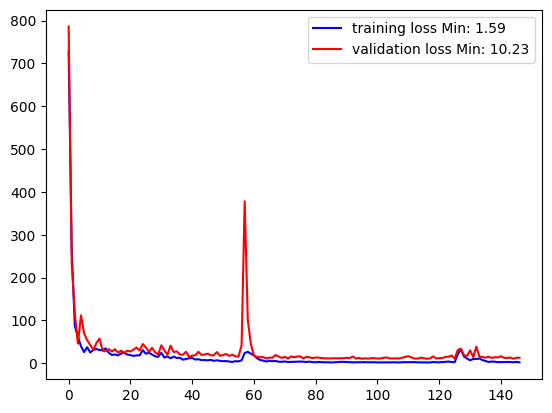

In [23]:
# 모델 학습 --------------------------------------------------------------------
#model = NvidiaModel().to(device)
#model = MobileNetSmall(num_outputs=1, dropout_p=0.2).to(device)
#model = EfficientNetSmall(num_outputs=1, dropout_p=0.2).to(device)
model = ShuffleNetV2Small(num_outputs=1, dropout_p=0.2).to(device)

def learnProc():
  BATCH_TRAIN = 32   # 또는 16, 64 등 GPU 상황 보고 조정
  BATCH_VALID = 64   # 검증은 grad가 없어서 조금 더 크게 줘도 됨

  train_dataset = CustomDataset(x_train_Image, y_train_Angle)
  #train_loader = DataLoader(train_dataset, batch_size=len(x_train_Image))
  train_loader = DataLoader(train_dataset, batch_size=BATCH_TRAIN, shuffle=True)

  valid_dataset = CustomDataset(x_valid_Image, y_valid_Angle)
  #valid_loader = DataLoader(valid_dataset, batch_size=len(x_valid_Image))
  valid_loader = DataLoader(valid_dataset, batch_size=BATCH_VALID, shuffle=True)

  #optimizer = optim.Adam(model.parameters(), lr=learnRate)
  #weight_decay = 1e-4 또는 1e-4
  optimizer = optim.Adam(model.parameters(), lr=learnRate, weight_decay=1e-4)
  criterion = nn.MSELoss().to(device)

  early_stopping = EarlyStopping(patience=30, verbose=True)

  train_losses = []
  valid_losses = []
  avg_train_losses = []
  avg_valid_losses = []
  for epoch in range(1, EPOCHS + 1):
      # 학습
      model.train()

      for batch_idx, (data, target) in enumerate(train_loader):
          data, target = data.to(device), target.to(device)
          optimizer.zero_grad()  #이전 반복에서 계산된 gradient(기울기)를 초기화(리셋)

          output = model(data)   #모델에 이미지를 넣어 예측값(출력) 생성

          loss = criterion(output.to(torch.float32), target.to(torch.float32))
          loss.backward()   #모델의 파라미터를 어떤 방향으로 얼마나 바꿔야 오차가 줄어드는지 계산
          optimizer.step()  #모델을 조금 더 정답에 가까운 방향으로 수정(업데이트)

          train_losses.append(loss.item())

      # 검증
      model.eval()

      with torch.no_grad():
        for data, target in valid_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)

            loss = criterion(output.to(torch.float32), target.to(torch.float32))

            valid_losses.append(loss.item())

      train_loss = np.average(train_losses)
      valid_loss = np.average(valid_losses)
      avg_train_losses.append(train_loss)
      avg_valid_losses.append(valid_loss)

      epoch_len = len(str(EPOCHS))

      print_msg = (f'[{epoch:>{epoch_len}}/{EPOCHS:>{epoch_len}}] ' +
                      f'train_loss: {train_loss:.6f} ' +
                      f'valid_loss: {valid_loss:.6f}')

      print(print_msg)

      train_losses = []
      valid_losses = []

      early_stopping(valid_loss, model)

      if early_stopping.early_stop:
          print("Early stopping")
          break

  return {'loss':avg_train_losses, 'val_loss':avg_valid_losses}

# 학습 시작---------------------------------------------------------------------
startTime = time.time()                                                         # 학습 시작 시간 저장
history = learnProc()                                                           # 학습 시작
elapsedTime = int(time.time() - startTime)                                      # 학습 경과 시간 저장
lossMin = min(history['loss'])                                                  # 딕셔너리 history의 'loss'키 데이터는 리스트, 최소값
val_lossMin = min(history['val_loss'])                                          # 딕셔너리 history의 'val_loss'키 데이터는 리스트, 최소값
#-------------------------------------------------------------------------------
plt.plot(history['loss'],color='blue')
plt.plot(history['val_loss'],color='red')
plt.legend([f'training loss Min: {lossMin:0.2f}', f'validation loss Min: {val_lossMin:0.2f}'])
plt.savefig(f'_{project}_result.png')                                           # plot 이미지 저장

<STEP 6> 학습 결과 표시, 테스트 파일 각도 예측

In [24]:
def resultShow():                                                               # 학습 완료후 통계자료를 보여줍니다.

  summary(model,(3, 66, 200))

  test_dataset = CustomDataset(x_exam_Image, y_exam_Angle)
  test_loader = DataLoader(test_dataset, batch_size=len(x_exam_Image))

  model.load_state_dict(torch.load(f'_{project}_model_check.pt'))               # 모델 파일
  model.eval()

  y_pred = []
  y_target = []

  with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            print('PREDICTED ANGLE')                                                              # GPU Edition
            print(output.to(device).cpu().numpy())                                                              # GPU Edition
            print('TARGET ANGLE')                                                            #
            print(target.to(device).cpu().numpy())                                                            #
            for output_data, target_data in zip(output.to(device).cpu().numpy(), target.to(device).cpu().numpy()):      #
              y_pred.append(output_data)
              y_target.append(target_data)

  mse = mean_squared_error(y_target, y_pred)
  r2s = r2_score(y_target, y_pred)
  #-----------------------------------------------------------------------------
  print('\n표준 편차:', f'{mse:.2f}')
  print('회귀 결정 계수:', f'{r2s:.2%}')
  #-----------------------------------------------------------------------------
  fig, axes = plt.subplots(1, len(x_exam_Image), figsize=(30, 2+3))
  xTImg = imgPaths(x_exam_Image)                                                # 파일 이름 앞에 경로(path) 추가
  for x, c in enumerate(xTImg):
    yuv_image = cv2.imread(c, cv2.IMREAD_UNCHANGED)                             # 테스트 이미지 읽기
    bgr_image = cv2.cvtColor(yuv_image, cv2.COLOR_YUV2BGR)                      # YUV 이미지를 BGR 형식으로 변환
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)                      # MatPlot Lib 에서 표시되는 RGB 형식으로 변환
    axes[x].imshow(rgb_image)
    t = x_exam_Image[x] +' / E:'+str(int(y_pred[x]))
    axes[x].set_title(t, fontsize=10)
    axes[x].xaxis.set_ticks([])
    axes[x].yaxis.set_ticks([])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 24, 33, 100]             648
       BatchNorm2d-2          [-1, 24, 33, 100]              48
              ReLU-3          [-1, 24, 33, 100]               0
            Conv2d-4           [-1, 24, 17, 50]             216
       BatchNorm2d-5           [-1, 24, 17, 50]              48
            Conv2d-6           [-1, 24, 17, 50]             576
       BatchNorm2d-7           [-1, 24, 17, 50]              48
              ReLU-8           [-1, 24, 17, 50]               0
            Conv2d-9          [-1, 24, 33, 100]             576
      BatchNorm2d-10          [-1, 24, 33, 100]              48
             ReLU-11          [-1, 24, 33, 100]               0
           Conv2d-12           [-1, 24, 17, 50]             216
      BatchNorm2d-13           [-1, 24, 17, 50]              48
           Conv2d-14           [-1, 24,

/tmp/ipython-input-2633214742.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t = x_exam_Image[x] +' / E:'+str(int(y_pred[x]))


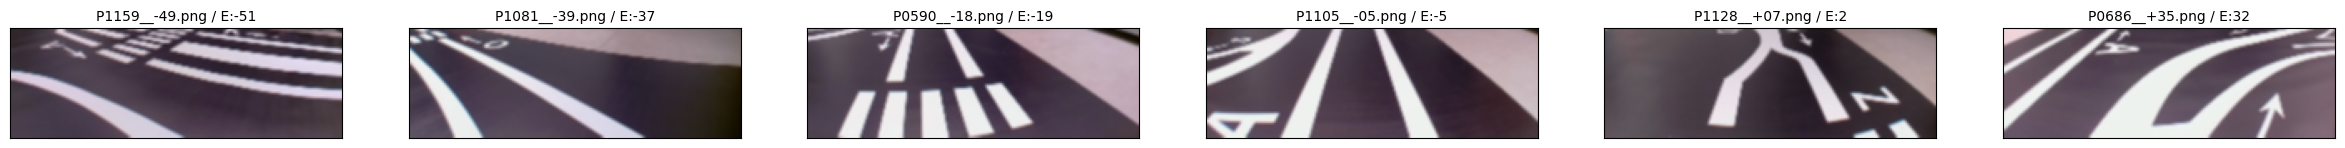

In [25]:
if len(x_exam_Image): resultShow()
print("학습 소요 시간:", int(elapsedTime/60), '분', elapsedTime%60, '초' )      # 학습 소요시간 프린트